In [1]:
## v3 edits : keep everything fully spatial till last moment, so i can plot maps

import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
#from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline
#import xesmf as xe
import matplotlib
from utils import QACC_utils
#from utils.config import model, min_lat, max_lat, min_year_late_cent, max_year_late_cent
##### SETTINGS
model = 'UKESM1-0-LL'
regions = ['Arctic', 'Tropics']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23]}
scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']
experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}
time_slice_dict = {'ssp245':['2050', '2070'], 
                   'ARISE':['2050', '2070'],
                   'ssp245_baseline':['2015', '2030']}

from utils.Utils import weighted_annual_resample, get_ds_from_ceda, spatial_mean

In [2]:
dict_list = []
for scen in scenarios:
    ds_list = []
    for region in regions:
        ds =  xr.open_dataset('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
            s=scen, l=str(lat_band_dict[region][0]), m=model))
        ds_list.append(ds)
    scen_dict = dict(zip(regions, ds_list))
    dict_list.append(scen_dict)
spatial_means_dict = dict(zip(scenarios, dict_list))

In [3]:
spatial_means_dict['ssp245_baseline']['Arctic']

<xarray.Dataset> Size: 9kB
Dimensions:                 (month: 12, bnds: 2, plev: 19)
Coordinates:
    height                  float64 8B ...
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev                    (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
Dimensions without coordinates: bnds
Data variables: (12/33)
    lat_bounds              (month, bnds) float64 192B ...
    lon_bounds              (month, bnds) float64 192B ...
    tas                     (month) float64 96B ...
    number_ens_mems_meaned  (month) float64 96B ...
    rsds                    (month) float64 96B ...
    rsus                    (month) float64 96B ...
    ...                      ...
    AHTmoist                (month) float64 96B ...
    AHTdry                  (month) float64 96B ...
    IRF_aer                 (month) float64 96B ...
    IRF_aer_cs              (month) float64 96B ...
    albedo                  (month) float64 96B ...
    CRE                     (month) float64 96B ...

Text(0.5, 0.98, 'AHT')

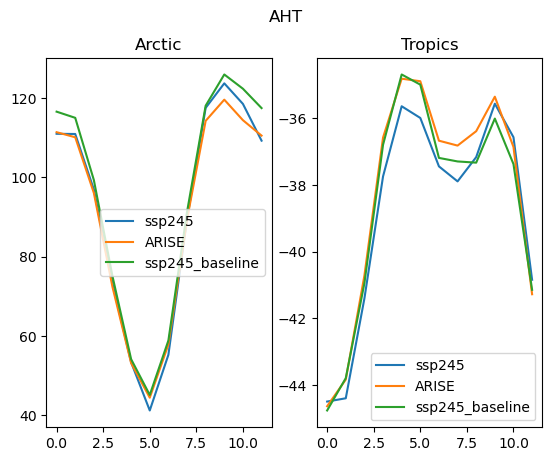

In [4]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].AHT.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('AHT')

Text(0.5, 0.98, 'OHU')

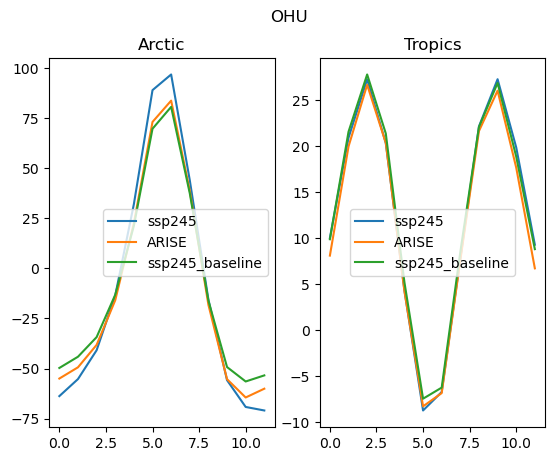

In [5]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].OHU.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('OHU')

In [6]:
os.listdir('intermediate_outputs/feedbacks/')

['baseline_ssp245_feedbacks.nc',
 'ssp245_ARISE_feedbacks.nc',
 'baseline_ARISE_feedbacks.nc']

In [7]:
# read in feedbacks (W/m2 - so R units)
Rs_sai = xr.open_dataset('intermediate_outputs/feedbacks/ssp245_ARISE_feedbacks.nc')
Rs_ssp = xr.open_dataset('intermediate_outputs/feedbacks/baseline_ssp245_feedbacks.nc')
Rs_sai_vs_baseline = xr.open_dataset('intermediate_outputs/feedbacks/baseline_ARISE_feedbacks.nc')


def add_extra_Rs(Rs):
    Planck_global_mean_lambda = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K
    Planck_global_mean_cs_lambda = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K

    Planck_global_mean = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat') # W/m2
    Planck_global_mean_cs = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat') # W/m2
    
    # this one is the real calc
    Rs['Planck_dash'] = (Rs['Planck']/Rs['delta_TS'] - Planck_global_mean_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units
    Rs['Planck_dash_cs'] = (Rs['Planck_cs']/Rs['delta_TS'] - Planck_global_mean_cs_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units

    # try simpler (but wrong, i think) planck calc to check it doesn fix things - it doesnt
    #Rs['Planck_dash'] = -(Rs['Planck'] - Planck_global_mean) 
    #Rs['Planck_dash_cs'] = -(Rs['Planck_cs'] - Planck_global_mean_cs) 
    
    Rs_arctic_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1])), 'lon', 'lat')
    Rs_tropics_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1])), 'lon', 'lat')

    # also save planck mean for later
    Rs_arctic_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    Rs_tropics_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    return Rs, Rs_arctic_mean, Rs_tropics_mean

Rs_sai, Rs_sai_arctic, Rs_sai_tropics = add_extra_Rs(Rs_sai)
Rs_ssp, Rs_ssp_arctic, Rs_ssp_tropics = add_extra_Rs(Rs_ssp)
Rs_sai_vs_baseline, Rs_sai_vs_baseline_arctic, Rs_sai_vs_baseline_tropics = add_extra_Rs(Rs_sai_vs_baseline)



Rs_dict = {'sai':{'Arctic':Rs_sai_arctic, 'Tropics':Rs_sai_tropics, 'Spatial':Rs_sai},
           'ssp':{'Arctic':Rs_ssp_arctic, 'Tropics':Rs_ssp_tropics, 'Spatial':Rs_ssp},
           'sai_vs_baseline':{'Arctic':Rs_sai_vs_baseline_arctic, 'Tropics':Rs_sai_vs_baseline_tropics, 'Spatial':Rs_sai_vs_baseline}}

### NB - the code is set up to allow this third scenario to run, i.e. to compare SAI against the target state (the baseline)
### BUT - the method doesn't work here, some thought is needed on how to apply it to the scenario without a strong signal in 
### delta T and an overall forcing. The breakdown is clear from the two arrays printed in below - planck should be negative 
### and cosistent, but isn't for the sai_vs_baseline case, so for now I will leave this case out. 
print(Rs_dict['sai']['Tropics']['Planck_global_mean_lambda'].values)
print(Rs_dict['sai_vs_baseline']['Tropics']['Planck_global_mean_lambda'].values)

[-3.16203443 -3.20297703 -3.25134889 -3.30078648 -3.32634303 -3.36176194
 -3.38721186 -3.37955992 -3.35978414 -3.28394959 -3.19775559 -3.16214225]
[-1.66507918 -1.47141815 -1.64364402 -1.0587235   3.93355058  6.98138596
 -4.92809952 11.22492874  2.1090017  -1.01519754 -1.1549494  -1.02155346]


In [8]:
ds_delta_sm_sai_arctic = (spatial_means_dict['ARISE']['Arctic'] - spatial_means_dict['ssp245']['Arctic']).rename({'month':'time'})
ds_delta_sm_ssp_arctic = (spatial_means_dict['ssp245']['Arctic'] - spatial_means_dict['ssp245_baseline']['Arctic']).rename({'month':'time'})
ds_delta_sm_sai_vs_baseline_arctic = (spatial_means_dict['ARISE']['Arctic'] - spatial_means_dict['ssp245_baseline']['Arctic']).rename({'month':'time'})

ds_delta_sm_sai_tropics = (spatial_means_dict['ARISE']['Tropics'] - spatial_means_dict['ssp245']['Tropics']).rename({'month':'time'})
ds_delta_sm_ssp_tropics = (spatial_means_dict['ssp245']['Tropics'] - spatial_means_dict['ssp245_baseline']['Tropics']).rename({'month':'time'})
ds_delta_sm_sai_vs_baseline_tropics = (spatial_means_dict['ARISE']['Tropics'] - spatial_means_dict['ssp245_baseline']['Tropics']).rename({'month':'time'})

print(ds_delta_sm_sai_arctic.tas.mean('time').item())
print(ds_delta_sm_ssp_arctic.tas.mean('time').item())
print(ds_delta_sm_sai_vs_baseline_arctic.tas.mean('time').item())

print(ds_delta_sm_sai_tropics.tas.mean('time').item())
print(ds_delta_sm_ssp_tropics.tas.mean('time').item())
print(ds_delta_sm_sai_vs_baseline_tropics.tas.mean('time').item())

deltas_dict = {'sai':{'Arctic':ds_delta_sm_sai_arctic, 'Tropics':ds_delta_sm_sai_tropics},
               'ssp':{'Arctic':ds_delta_sm_ssp_arctic, 'Tropics':ds_delta_sm_ssp_tropics},
               'sai_vs_baseline':{'Arctic':ds_delta_sm_sai_vs_baseline_arctic, 'Tropics':ds_delta_sm_sai_vs_baseline_tropics}}

-3.7508027092677856
5.231382299270993
1.480579590003207
-1.479591238254874
1.419335654085027
-0.06025558416984703


In [9]:
all_feedbacks = ['Planck', 'Alb', 'LR', 'WV', 'T_strat', 'q_strat']

dict_list = []
for scen in ['sai', 'ssp', 'sai_vs_baseline']:
    ds_list = []
    for region in regions:
        Rs = Rs_dict[scen][region]
        delta_ds = deltas_dict[scen][region]
        feedback_masking = sum([(Rs[str(feedback+'_cs')] - Rs[feedback]) for feedback in all_feedbacks])
        IRF_masking = -1*(delta_ds['IRF_aer_cs'] - delta_ds['IRF_aer'])
        cloud_R = delta_ds['CRE'] + IRF_masking + feedback_masking
        ds_list.append(cloud_R)
    regions_cloudR_dict = dict(zip(regions, ds_list))
    dict_list.append(regions_cloudR_dict)
cloudR_dict = dict(zip(['sai', 'ssp', 'sai_vs_baseline'], dict_list))

In [10]:
def get_delta_T_contribs_dict(scen, region):
    
    Rs = Rs_dict[scen][region]
    ds_delta_sm = deltas_dict[scen][region]
    Planck_global_mean_lambda = Rs['Planck_global_mean_lambda']
    cloud_R = cloudR_dict[scen][region]
    
    delta_T_contribs = {
        'F':-(ds_delta_sm['IRF_aer'] + Rs['T_strat'] + Rs['q_strat'])/Planck_global_mean_lambda, # include strat adjustement, to get F from IRF
        #'F':-(ds_delta_sm['IRF_aer'])/Planck_global_mean_lambda, # test without strat adjustment
        'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
        'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda, # our OHU is defined the 'wrong' way round, positive into the ocean
        'Planck':-Rs['Planck_dash']/Planck_global_mean_lambda,
        'Alb':-Rs['Alb']/Planck_global_mean_lambda,
        'LR':-Rs['LR']/Planck_global_mean_lambda,
        'WV':-Rs['WV']/Planck_global_mean_lambda,
        'Cloud':-cloud_R/Planck_global_mean_lambda}
    
    if scen == 'ssp':
        del delta_T_contribs['F'] # F is the aerosol forcing, not meaningful for ssp warming
        
    return delta_T_contribs

In [11]:
## colorscheme for all contributions:
color_scheme = {
     'F': '#e57373',       # Muted red
    'AHT': '#64b5f6',     # Sky blue
    'OHU': '#81c784',     # Mint green
    'Planck': '#ba68c8',  # Soft purple
    'Alb': '#ffb74d',     # Burnt orange
    'LR': '#fff176',      # Pastel yellow
    'WV': '#a1887f',      # Dusty brown
    'Cloud': '#f06292',    # Pale pink
    'Residual':'dimgrey'
}

process_labels = {'F':'F_aer',
                  'AHT':'AHT',
                  'OHU':'OHU',
                  'Planck':'Planck',
                  'Alb':'Albedo',
                  'LR':'Lapse Rate',
                  'WV':'Water vapour',
                  'Cloud':'Cloud'}

In [12]:
matplotlib.rcParams.update({'font.size': 15})

Text(0.5, 1.0, 'ΔT contribitions: sai: Arctic')

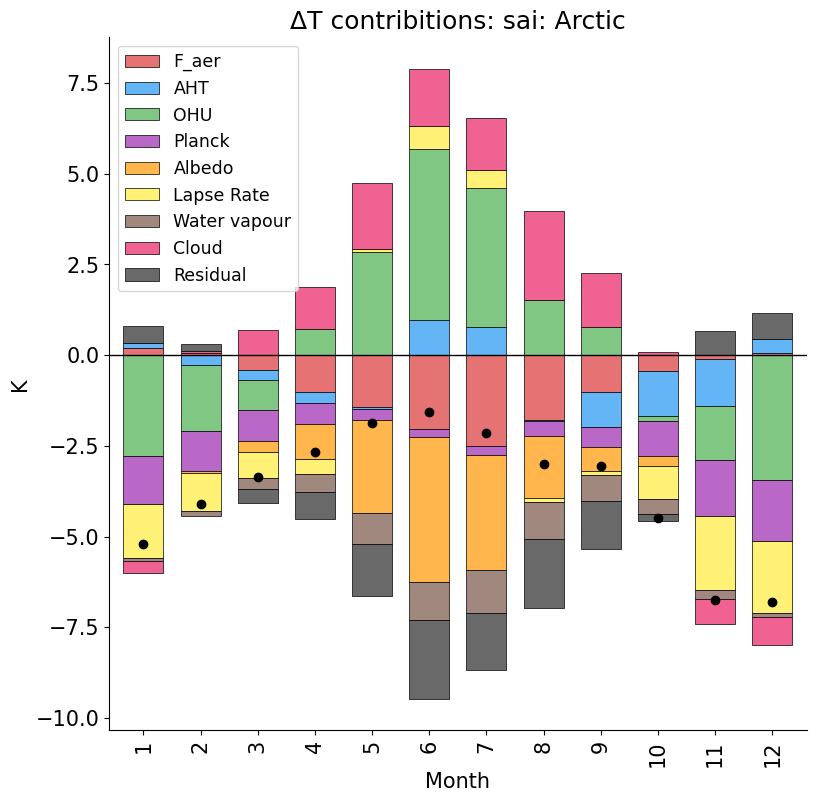

In [13]:
# quick example plot
scen, region = 'sai', 'Arctic'
df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))

df['Month'] = Rs_dict[scen][region].time.values
total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
residuals = deltas_dict[scen][region].tas.values - total_T_contribs
df['Residual'] = residuals

df_rn = df.rename(columns=process_labels) # full words for labels

fig, ax = plt.subplots(1, 1, figsize = (9, 9))#, sharey=True)
i=0
df_rn.plot(kind = "bar",
        x='Month',
        stacked = True,
        ax = ax,
        width = 0.7,
        edgecolor = "black", lw=0.5,
        color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
#ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
ax.set_ylabel('K')
ax.axhline(y=0, c='black', lw=1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(fontsize='small', loc='upper left', ncols=1)
ax.set_title('ΔT contribitions: {s}: {r}'.format(s=scen, r=region))

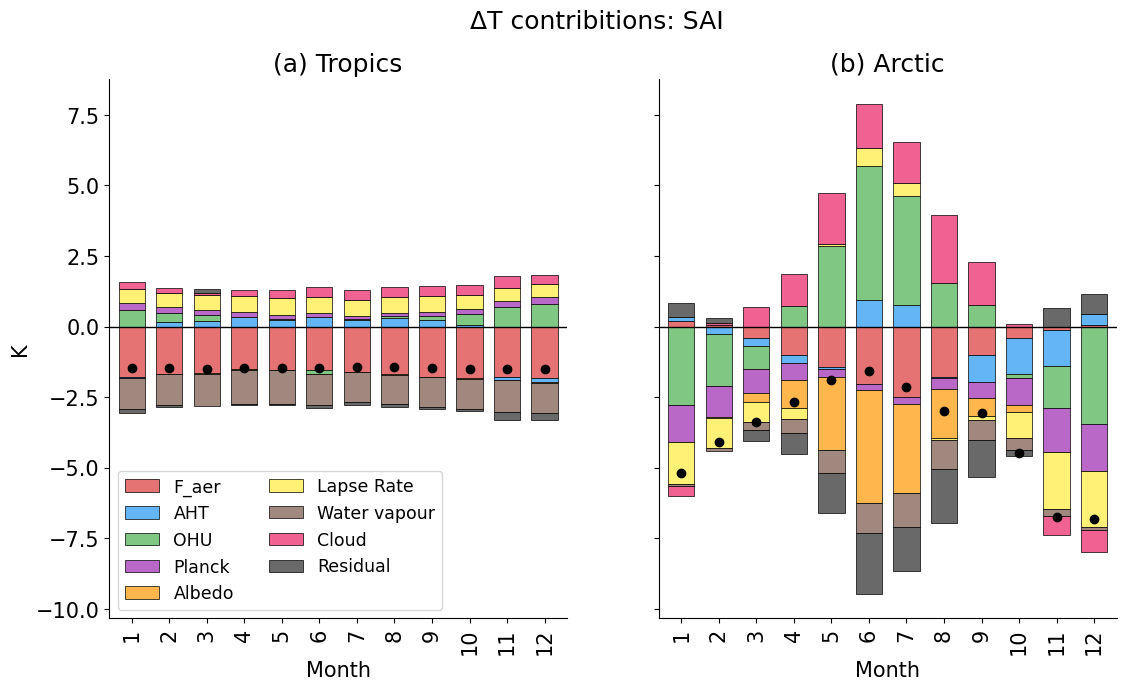

In [14]:
### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (13, 7),
                       sharey=True, sharex=True)

scen = 'sai'
titles = ['(a) Tropics', '(b) Arctic']
i=0
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    df['Residual'] = residuals
    df_rn = df.rename(columns=process_labels)
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SAI')

plt.savefig('figures/Arctic_and_tropical_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

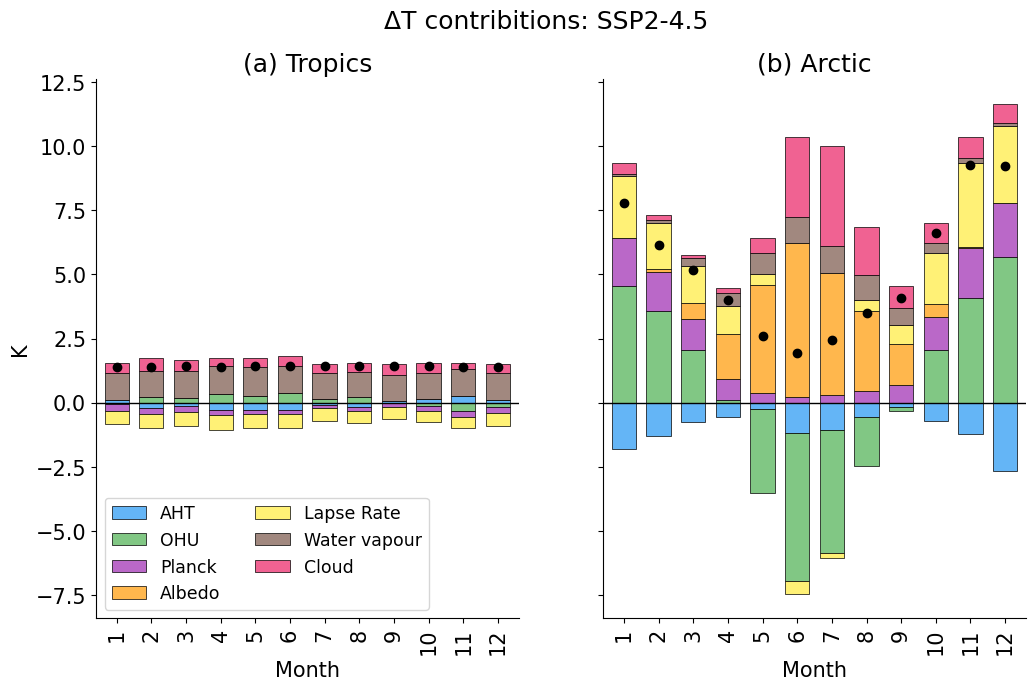

In [15]:
### note - can't do residuals, total T or forcing for SSP cause we dont have it

fig, axs = plt.subplots(1, 2, figsize = (12, 7),
                       sharey=True, sharex=True)

scen = 'ssp'
i=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    df_rn = df.rename(columns=process_labels)
    #df = df.drop(columns=['F'])
    #total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    #df['Residual'] = residuals
    
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SSP2-4.5')

plt.savefig('figures/Arctic_and_tropical_warming_contribs.jpg', dpi=300, bbox_inches='tight')

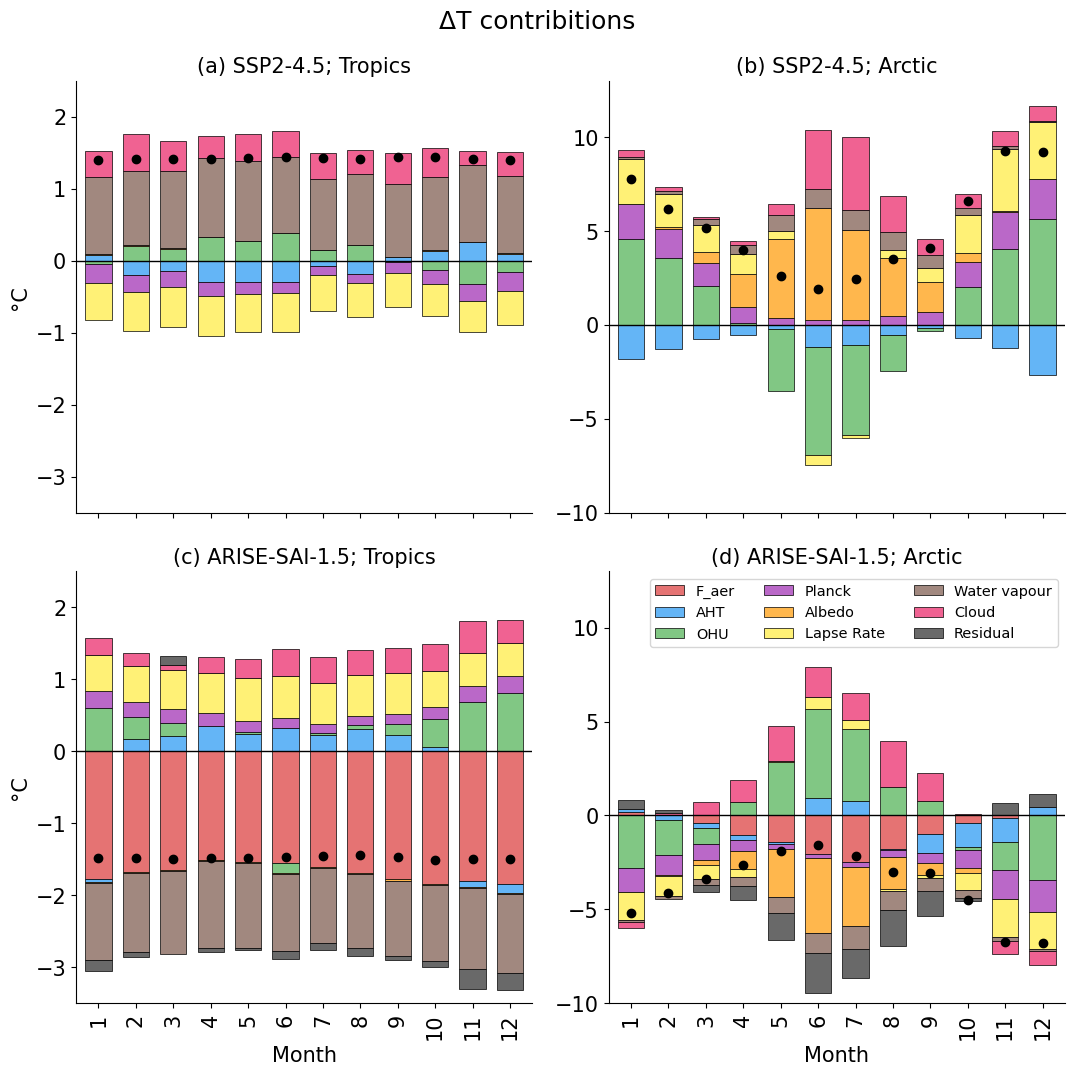

In [16]:
### combine the two plots above into one fig:

fig, axs = plt.subplots(2, 2, figsize = (11, 11), sharey=False, sharex=True)


scen = 'sai'
titles = ['(a) SSP2-4.5; Tropics', '(b) SSP2-4.5; Arctic',
          '(c) ARISE-SAI-1.5; Tropics', '(d) ARISE-SAI-1.5; Arctic']

ylims = {'Tropics':[-3.5, 2.5], 'Arctic':[-10, 13]}
i, j, k = 0, 0, 0
for scen in ['ssp', 'sai']:
    j=0
    for region in ['Tropics', 'Arctic']:

        df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
        df['Month'] = Rs_dict[scen][region].time.values

        if scen == 'sai':
            total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
            residuals = deltas_dict[scen][region].tas.values - total_T_contribs
            df['Residual'] = residuals
        df_rn = df.rename(columns=process_labels)

        ax = axs[i, j]
        
        df_rn.plot(kind = "bar",
                x='Month',
                stacked = True,
                ax = ax,
                width = 0.7,
                edgecolor = "black", lw=0.5, legend=False,
                color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
        
        ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
        #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
        if region == 'Tropics':
            ax.set_ylabel('°C')
        ax.axhline(y=0, c='black', lw=1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_title(titles[k], fontsize='medium')
        ax.set_ylim(ylims[region])
        j=j+1
        k=k+1
    i=i+1


axs[1,1].legend(fontsize='x-small', loc='upper right', ncols=3)
plt.suptitle('ΔT contribitions', fontsize='large')
plt.tight_layout()
plt.savefig('figures/Arctic_and_tropical_warming_and_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

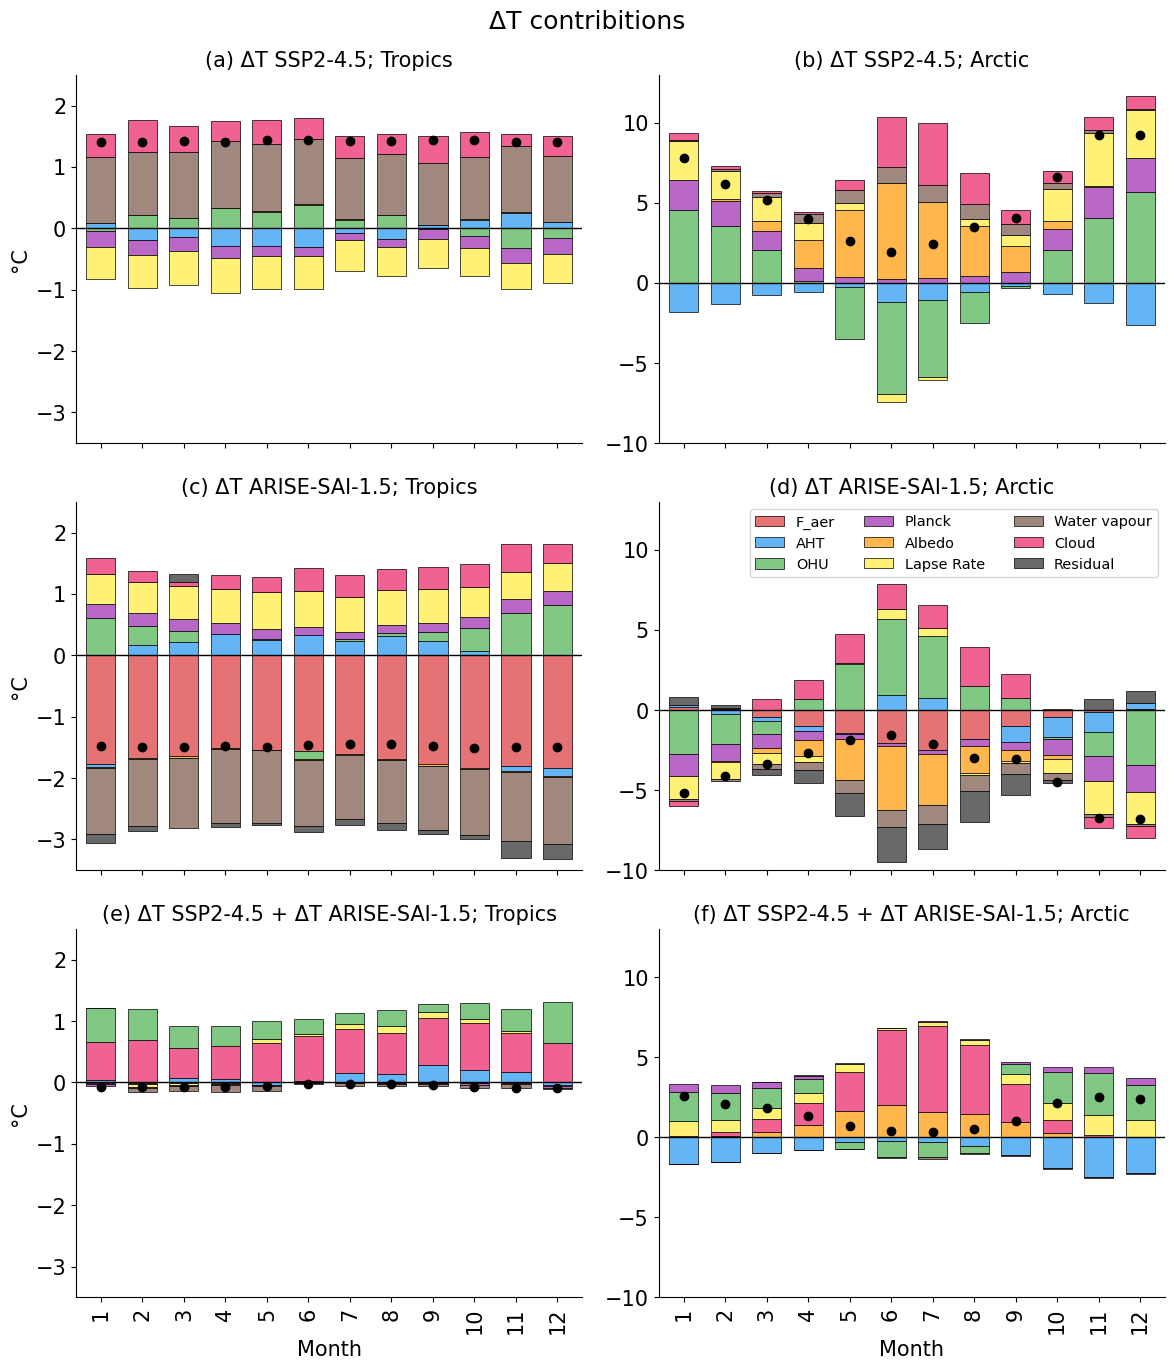

In [17]:
### final version, with difference between SSP245 changes and SAI changes, as a third row: 

### combine the two plots above into one fig:

fig, axs = plt.subplots(3, 2, figsize = (12, 14), sharey=False, sharex=True)


scen = 'sai'
titles = ['(a) ΔT SSP2-4.5; Tropics', '(b) ΔT SSP2-4.5; Arctic',
          '(c) ΔT ARISE-SAI-1.5; Tropics', '(d) ΔT ARISE-SAI-1.5; Arctic', 
          '(e) ΔT SSP2-4.5 + ΔT ARISE-SAI-1.5; Tropics', '(f) ΔT SSP2-4.5 + ΔT ARISE-SAI-1.5; Arctic']

ylims = {'Tropics':[-3.5, 2.5], 'Arctic':[-10, 13]}
i, j, k = 0, 0, 0
for scen in ['ssp', 'sai']:
    j=0
    for region in ['Tropics', 'Arctic']:

        df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
        df['Month'] = Rs_dict[scen][region].time.values

        if scen == 'sai':
            total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
            residuals = deltas_dict[scen][region].tas.values - total_T_contribs
            df['Residual'] = residuals
        df_rn = df.rename(columns=process_labels)

        ax = axs[i, j]
        
        df_rn.plot(kind = "bar",
                x='Month',
                stacked = True,
                ax = ax,
                width = 0.7,
                edgecolor = "black", lw=0.5, legend=False,
                color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
        
        ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
        #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
        if region == 'Tropics':
            ax.set_ylabel('°C')
        ax.axhline(y=0, c='black', lw=1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_title(titles[k], fontsize='medium')
        ax.set_ylim(ylims[region])
        j=j+1
        k=k+1
    i=i+1

axs[1,1].legend(fontsize='x-small', loc='upper right', ncols=3)

j=0
# now do the difference plot:
for region in ['Tropics', 'Arctic']:
    df_sai, df_ssp = pd.DataFrame(get_delta_T_contribs_dict('sai', region)), pd.DataFrame(get_delta_T_contribs_dict('ssp', region))
    df = df_ssp + df_sai
    df['Month'] = Rs_dict[scen][region].time.values
    df_rn = df.rename(columns=process_labels)
    ax = axs[2, j]
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, (deltas_dict['ssp'][region].tas + deltas_dict['sai'][region].tas).values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    if region == 'Tropics':
        ax.set_ylabel('°C')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[k], fontsize='medium')
    ax.set_ylim(ylims[region])
    j=j+1
    k=k+1


plt.suptitle('ΔT contribitions', fontsize='large')
plt.tight_layout()
plt.savefig('figures/Arctic_and_tropical_warming_and_cooling_contribs_plus_deltas.jpg', dpi=300, bbox_inches='tight')

In [18]:
breaks

NameError: name 'breaks' is not defined

In [ ]:
df_sai, df_ssp = pd.DataFrame(get_delta_T_contribs_dict('sai', region)), pd.DataFrame(get_delta_T_contribs_dict('ssp', region))

In [ ]:
"""

fig, axs = plt.subplots(1, 2, figsize = (13, 7),
                       sharey=True, sharex=True)

scen = 'sai_vs_baseline'
titles = ['(a) Tropics', '(b) Arctic']
i=0
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    #total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    #df['Residual'] = residuals
    df_rn = df.rename(columns=process_labels)
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SAI vs baseline')

#plt.savefig('figures/Arctic_and_tropical_cooling_contribs.jpg', dpi=300, bbox_inches='tight')
"""

'\n\nfig, axs = plt.subplots(1, 2, figsize = (13, 7),\n                       sharey=True, sharex=True)\n\nscen = \'sai_vs_baseline\'\ntitles = [\'(a) Tropics\', \'(b) Arctic\']\ni=0\nfor region in [\'Tropics\', \'Arctic\']:\n\n    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))\n    df[\'Month\'] = Rs_dict[scen][region].time.values\n    #total_T_contribs = df.drop(columns=[\'Month\']).sum(axis=1)\n    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs\n    #df[\'Residual\'] = residuals\n    df_rn = df.rename(columns=process_labels)\n    ax = axs[i]\n    \n    df_rn.plot(kind = "bar",\n            x=\'Month\',\n            stacked = True,\n            ax = ax,\n            width = 0.7,\n            edgecolor = "black", lw=0.5, legend=False,\n            color=[color_scheme[col] for col in df.drop(columns=[\'Month\']).columns])\n    \n    ax.scatter(df[\'Month\']-1, deltas_dict[scen][region].tas.values, c=\'black\')\n    #ax.scatter(df[\'Month\']-1, total_T_

In [ ]:
scen = 'sai'
df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()

list(df_t)

[-1.6865590946305382,
 0.15658759193395932,
 0.25685351416774527,
 0.17785054469805647,
 -0.01580902085978278,
 0.5319650987008906,
 -1.096675027882652,
 0.293844156453215]

In [ ]:
df_t

F        -1.686559
AHT       0.156588
OHU       0.256854
Planck    0.177851
Alb      -0.015809
LR        0.531965
WV       -1.096675
Cloud     0.293844
dtype: float64

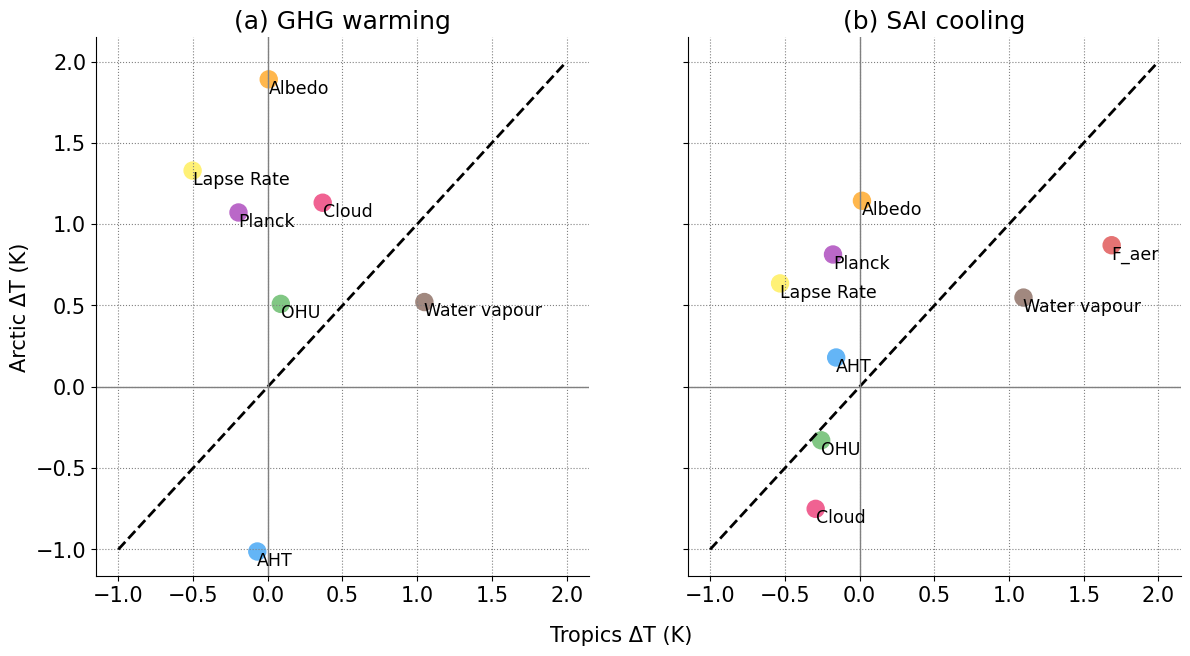

In [ ]:
## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (14, 7),
                       sharey=True, sharex=True)
l=0
titles=['(a) GHG warming', '(b) SAI cooling']
for scen in ['ssp', 'sai']:
    ax = axs[l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    
    l=l+1

axs[0].set_ylabel('Arctic ΔT (K)', fontsize='medium')
fig.supxlabel('Tropics ΔT (K)', fontsize='medium')
plt.savefig('figures/Arctic_vs_tropical_warming_and_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

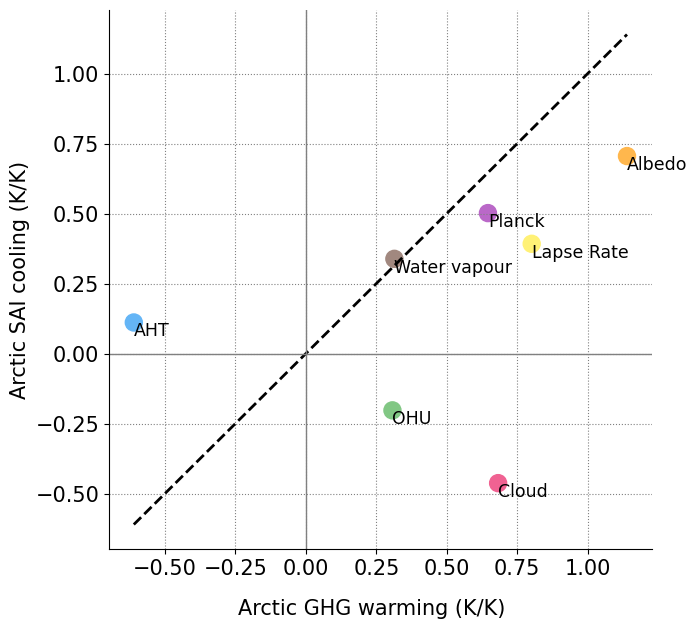

In [ ]:

## plot the arctic warming vs arctic cooling contributions under sai

region = 'Arctic'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()


line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

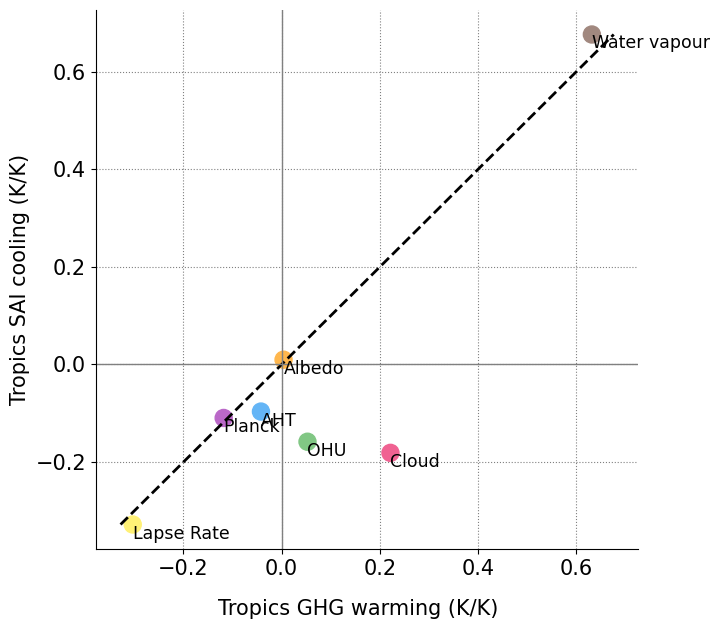

In [ ]:

region = 'Tropics'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()

line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

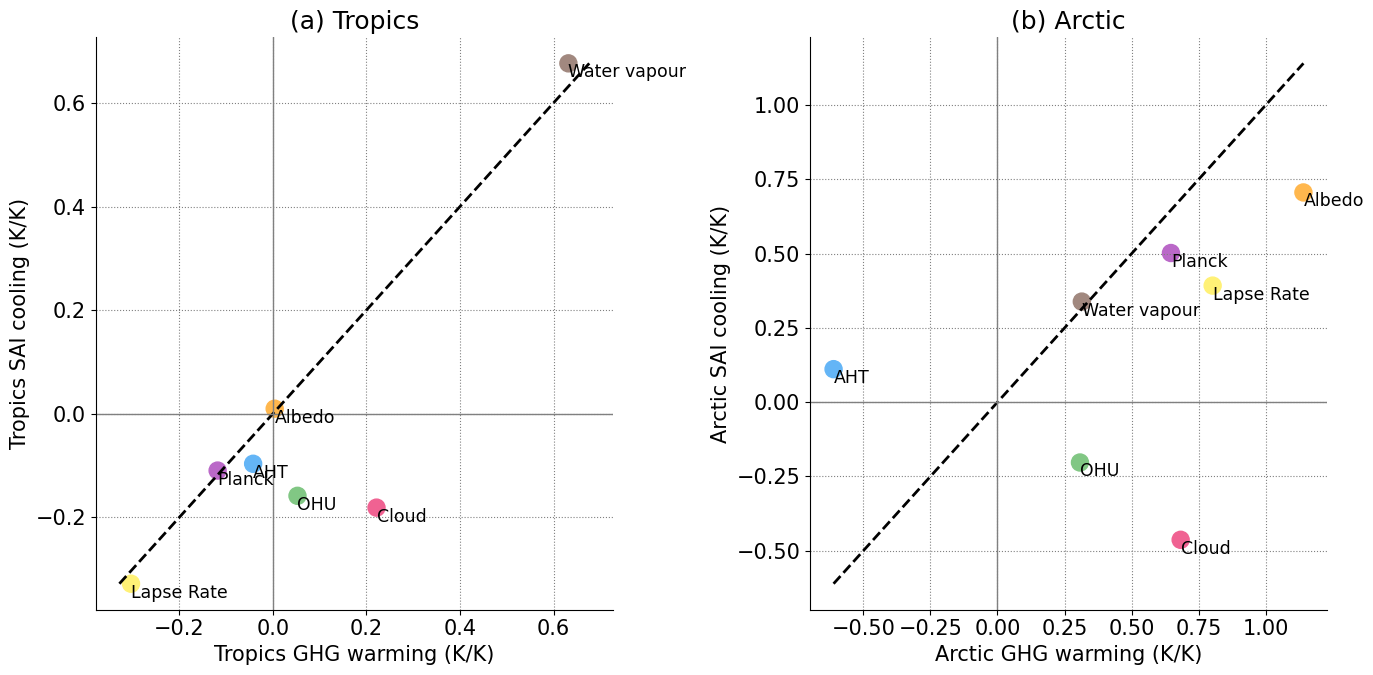

In [ ]:
## combine into one:

fig, axs = plt.subplots(1, 2, figsize = (14, 7))

l=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:
    ax = axs[l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/Both_regs_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

In [ ]:
np.min([np.min(df_x), np.min(df_y)])

-0.6106181850665944

In [ ]:
process_labels2 = {'F':'F_aer',
                  'AHT':'AHT',
                  'OHU':'OHU',
                  'Planck':'Planck',
                  'Alb':'Albedo',
                  'LR':'Lapse Rate',
                  'WV':'Water\nvapour',
                  'Cloud':'Cloud'}

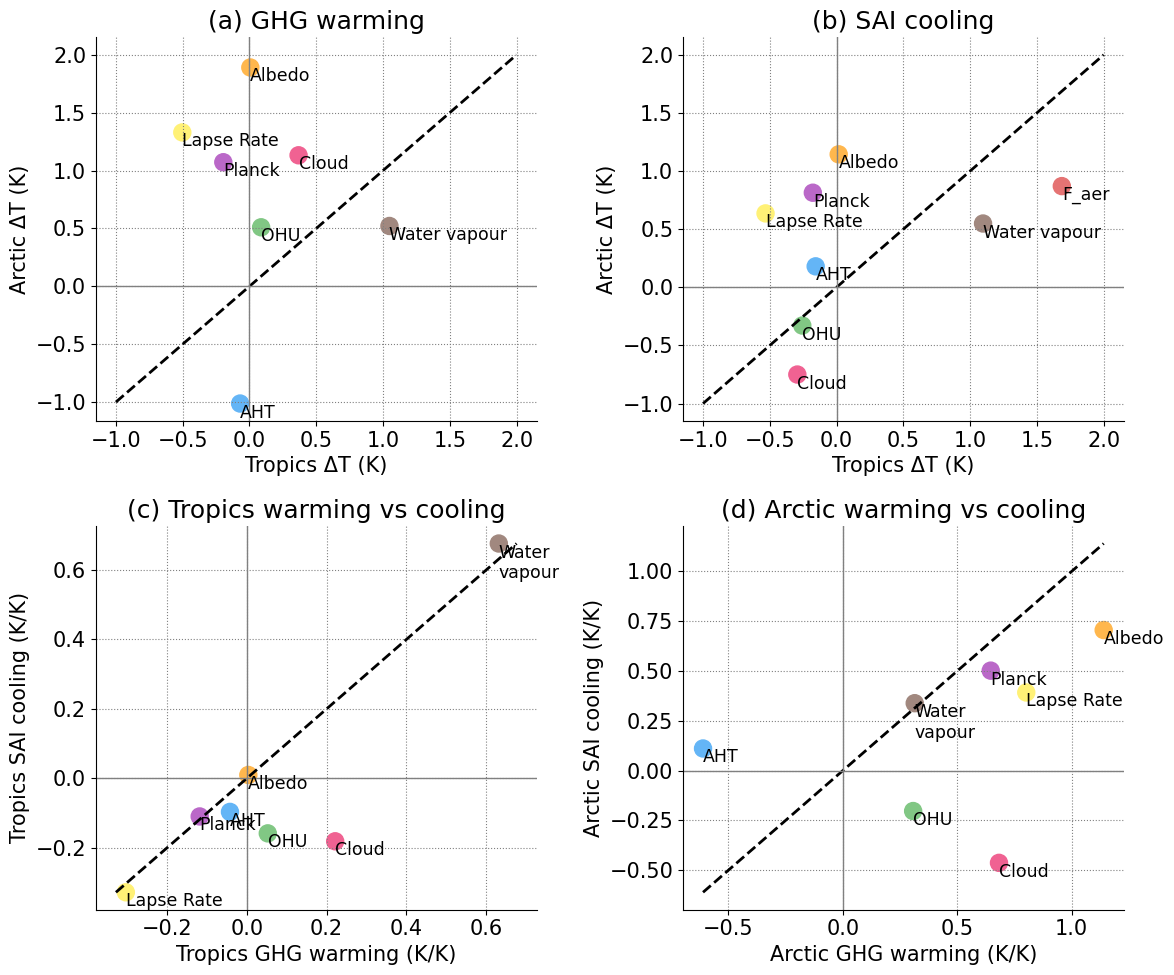

In [ ]:
## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 10),)
                       #sharey=True, sharex=True)

l=0
titles=['(a) GHG warming', '(b) SAI cooling']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics ΔT (K)', fontsize='medium')
    ax.set_ylabel('Arctic ΔT (K)', fontsize='medium')
    l=l+1



l=0
titles = ['(c) Tropics warming vs cooling', '(d) Arctic warming vs cooling']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/all_warming_vs_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

In [ ]:
### now add some maps:

## need to read in the spatial forcing and CRE (because i didn't save it spatially before):

rad_flux_vars_TOA = ['rsdt', 'rsut', 'rlut', 'rlutcs', 'rsutcs', 'rsutaf', 'rsutcsaf']
rad_flux_vars_surf = ['rsds', 'rsus', 'rlds', 'rlus', 'hfls', 'hfss']

def get_F_CRE(ds):
    # add OHU
    ds['OHU'] = ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss
    ## adds F, albedo, and CRE, and saves:
    # add IRF, allsky and clearsky
    ds['IRF_aer'] = ds['rsutaf'] - ds['rsut']  # sign convention here is that more SW to space is a negative forcing
    ds['IRF_aer_cs'] = ds['rsutcsaf'] - ds['rsutcs']
    # add CRE (cloud radiative effect))
    ds['CRE'] = ((ds['rsutcs']-ds['rsut'])+(ds['rlutcs']-ds['rlut']))
    return ds

ds_F_ssp245 = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ssp245',
                                                    min_year=time_slice_dict['ssp245'][0],
                                                    max_year=time_slice_dict['ssp245'][1]))

ds_F_ssp245_baseline = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ssp245',
                                                    min_year=time_slice_dict['ssp245_baseline'][0],
                                                    max_year=time_slice_dict['ssp245_baseline'][1]))

ds_F_arise = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ARISE',
                                                   min_year=time_slice_dict['ARISE'][0],
                                                   max_year=time_slice_dict['ARISE'][1]))

  0%|          | 0/13 [00:00<?, ?it/s]

rsdt


  8%|▊         | 1/13 [00:02<00:28,  2.36s/it]

rsut


 15%|█▌        | 2/13 [00:06<00:39,  3.55s/it]

...

 85%|████████▍ | 11/13 [00:17<00:02,  1.45s/it]

hfls


 92%|█████████▏| 12/13 [00:19<00:01,  1.57s/it]

hfss


100%|██████████| 13/13 [00:21<00:00,  1.65s/it]


In [ ]:

ds_F_sai = (ds_F_arise - ds_F_ssp245).rename({'x':'lon', 'y':'lat', 'month':'time'})
feedback_masking = sum([(Rs_dict['sai']['Spatial'][str(feedback+'_cs')] - Rs_dict['sai']['Spatial'][feedback]) for feedback in all_feedbacks])
IRF_masking = -1*(ds_F_sai['IRF_aer_cs'] - ds_F_sai['IRF_aer'])
cloud_R_sai = (ds_F_sai['CRE'] + IRF_masking + feedback_masking).load()

ds_F_ssp = (ds_F_ssp245 - ds_F_ssp245_baseline).rename({'x':'lon', 'y':'lat', 'month':'time'})
feedback_masking = sum([(Rs_dict['ssp']['Spatial'][str(feedback+'_cs')] - Rs_dict['ssp']['Spatial'][feedback]) for feedback in all_feedbacks])
IRF_masking = -1*(ds_F_ssp['IRF_aer_cs'] - ds_F_ssp['IRF_aer'])
cloud_R_ssp = (ds_F_ssp['CRE'] + IRF_masking + feedback_masking).load()

cloud_Rs_dict = {'sai':cloud_R_sai, 'ssp':cloud_R_ssp}

In [ ]:
ds_F_sai

<xarray.Dataset> Size: 23MB
Dimensions:                 (lat: 144, lon: 192, time: 12, bnds: 2)
Coordinates:
  * lat                     (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                     (lon) float64 2kB 0.9375 2.812 4.688 ... 357.2 359.1
  * time                    (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables: (12/20)
    lat_bounds              (time, lat, bnds) float64 28kB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    lon_bounds              (time, lon, bnds) float64 37kB dask.array<chunksize=(1, 192, 2), meta=np.ndarray>
    rsdt                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    number_ens_mems_meaned  (time) float64 96B -10.0 -10.0 -10.0 ... -10.0 -10.0
    rsut                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    rlut                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    ...                      ...
    hfls                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    hfss                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    OHU                     (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    IRF_aer                 (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    IRF_aer_cs              (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    CRE                     (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>

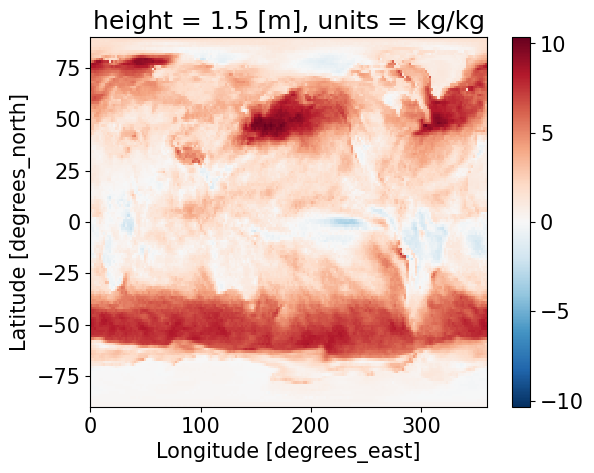

In [ ]:
cloud_R_sai.mean('time').plot()

In [ ]:
Rs_dict[scen]['Arctic']

<xarray.Dataset> Size: 2kB
Dimensions:                    (time: 12)
Coordinates:
  * time                       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height                     float64 8B ...
    units                      <U5 20B ...
Data variables: (12/16)
    LR                         (time) float64 96B -4.663 -3.369 ... -6.272
    Planck                     (time) float64 96B 12.23 9.63 ... 16.59 16.21
    WV                         (time) float64 96B -0.2853 -0.3899 ... -0.3404
    Alb                        (time) float64 96B -0.01005 ... -9.017e-05
    LR_cs                      (time) float64 96B -3.607 -2.587 ... -4.958
    Planck_cs                  (time) float64 96B 12.86 10.16 ... 17.7 17.12
    ...                         ...
    q_strat                    (time) float64 96B -0.02312 -0.04868 ... -0.03911
    q_strat_cs                 (time) float64 96B -0.02474 -0.05062 ... -0.04083
    delta_TS                   (time) float64 96B -5.191 -4.106 ... -6.814
    Planck_dash                (time) float64 96B -4.19 -3.52 ... -4.949 -5.336
    Planck_dash_cs             (time) float64 96B -4.935 -4.111 ... -6.233
    Planck_global_mean_lambda  (time) float64 96B -3.162 -3.203 ... -3.162

In [ ]:
def get_delta_T_contribs_spatial_dict(scen):
    
    Rs = Rs_dict[scen]['Spatial']
    ds_delta_sm = ds_F_sai if scen == 'sai' else ds_F_ssp
    Planck_global_mean_lambda = Rs_dict[scen]['Arctic']['Planck_global_mean_lambda']
    cloud_R = cloud_Rs_dict[scen]
    
    delta_T_contribs = {
        'F':-(ds_delta_sm['IRF_aer'] + Rs['T_strat'] + Rs['q_strat'])/Planck_global_mean_lambda, # include strat adjustement, to get F from IRF
        #'F':-(ds_delta_sm['IRF_aer'])/Planck_global_mean_lambda, # test without strat adjustment
        #'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
        'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda, # our OHU is defined the 'wrong' way round, positive into the ocean
        'Planck':-Rs['Planck_dash']/Planck_global_mean_lambda,
        'Alb':-Rs['Alb']/Planck_global_mean_lambda,
        'LR':-Rs['LR']/Planck_global_mean_lambda,
        'WV':-Rs['WV']/Planck_global_mean_lambda,
        'Cloud':-cloud_R/Planck_global_mean_lambda}
    
    if scen == 'ssp':
        del delta_T_contribs['F'] # F is the aerosol forcing, not meaningful for ssp warming
        
    return delta_T_contribs

In [ ]:
sai_spatial = get_delta_T_contribs_spatial_dict('sai')

In [ ]:
sai_spatial['F'].time

<xarray.DataArray 'time' (time: 12)> Size: 96B
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
Coordinates:
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height   float64 8B 1.5
    units    <U5 20B 'kg/kg'

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [ ]:
### sea ice

ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']

DS_ssp245_SI_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=ens_mems_arise_UK, 
                              table='SImon', grid='gr').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()
DS_ssp245_SI_UK = DS_ssp245_SI_UK.sel(time=slice(time_slice_dict['ssp245'][0], time_slice_dict['ssp245'][1])).mean('Ensemble_member')

### get siconca for ARISE
paths_si = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/SImon/siconca/gr/*/')
ds_list_si = []
for path in paths_si:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_si.append(ds)
DS_ARISE_siconca = xr.concat(ds_list_si, dim='Ensemble_member').sel(time=slice(time_slice_dict['ARISE'][0], time_slice_dict['ARISE'][1])).mean('Ensemble_member').load()

DS_ARISE_siconca = DS_ARISE_siconca.groupby(DS_ARISE_siconca.time.dt.month).mean()
DS_ssp245_SI_UK = DS_ssp245_SI_UK.groupby(DS_ssp245_SI_UK.time.dt.month).mean()

In [ ]:

delta_siconca = DS_ARISE_siconca['siconca'] - DS_ssp245_SI_UK['siconca']

In [ ]:
Rs_dict[scen]['Spatial']['delta_TS']

<xarray.DataArray 'delta_TS' (time: 12, lat: 144, lon: 192)> Size: 1MB
array([[[ -1.330521,  -1.329391, ...,  -1.333374,  -1.332321],
        [ -1.347137,  -1.344864, ...,  -1.347794,  -1.346893],
        ...,
        [ -8.623703,  -8.637344, ...,  -8.588272,  -8.607666],
        [ -8.891312,  -8.892395, ...,  -8.89151 ,  -8.891785]],

       [[ -1.230499,  -1.231552, ...,  -1.228867,  -1.232651],
        [ -1.250015,  -1.252487, ...,  -1.245361,  -1.249908],
        ...,
        [ -6.045349,  -6.066452, ...,  -6.00737 ,  -6.028671],
        [ -6.227768,  -6.228195, ...,  -6.225906,  -6.225143]],

       ...,

       [[ -1.39061 ,  -1.392456, ...,  -1.383301,  -1.387573],
        [ -1.5784  ,  -1.581039, ...,  -1.565536,  -1.576324],
        ...,
        [-13.804916, -13.784027, ..., -13.856903, -13.828781],
        [-14.122711, -14.119461, ..., -14.130249, -14.126312]],

       [[ -0.838821,  -0.837799, ...,  -0.838379,  -0.837173],
        [ -0.89093 ,  -0.893112, ...,  -0.89006 ,  -0.893845],
        ...,
        [-12.690536, -12.709961, ..., -12.632126, -12.665237],
        [-12.887955, -12.891205, ..., -12.883911, -12.8862  ]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height   float64 8B ...
    units    <U5 20B ...

/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_2143930/2418459360.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


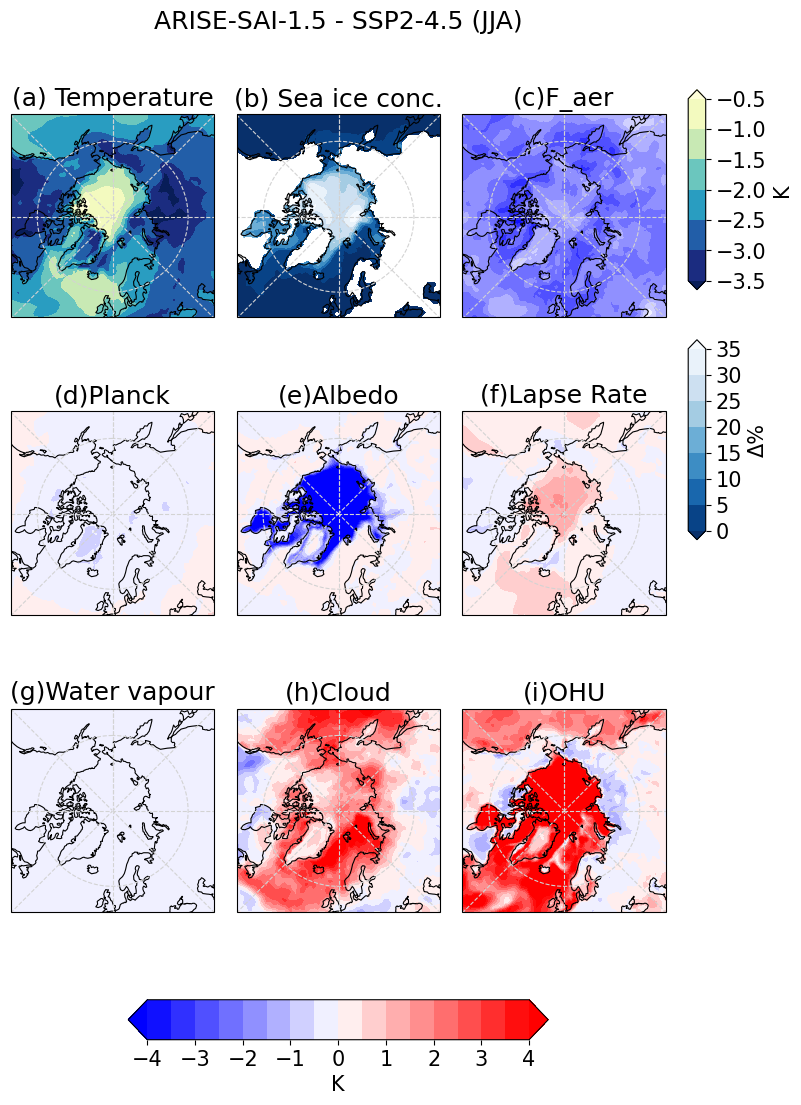

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(7, 10), subplot_kw={'projection': ccrs.NorthPolarStereo()})

extent = [-180, 180, 50, 90] 

month_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              'DJF': [12, 1, 2],
              'MAM': [3, 4, 5],
              'JJA': [6, 7, 8],
              'SON': [9, 10, 11]}

season = 'JJA'

T_levs = {'DJF':np.arange(-10, -1, 1),
          'Annual mean':np.arange(-3, -1, 0.25),
          'JJA':np.arange(-3.5, 0, 0.5),}

i = 0
data = Rs_dict[scen]['Spatial']['delta_TS']
data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
data = data.sel(lat=slice(30, 90))
cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
ax = axes.flatten()[i]
cont_T = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                    transform=ccrs.PlateCarree(),
                    levels=T_levs[season],
                    cmap='YlGnBu_r',
                    extend='both')
ax.set_title('(a) Temperature')
i=i+1


data = delta_siconca.where(delta_siconca.month.isin(month_dict[season]), drop=True).mean('month')
cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['longitude'])
ax = axes.flatten()[i]
cont_SI = ax.contourf(cyclic_lons, data['latitude'], cyclic_data,
                    transform=ccrs.PlateCarree(),
                    levels=np.arange(0, 40, 5),
                    cmap='Blues_r',
                    extend='both')
ax.set_title('(b) Sea ice conc.')
i=i+1

j=0
levels = np.arange(-4, 4.2, 0.5)
subtitle_labs = ['(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']
for feedback in ['F', 'Planck', 'Alb', 'LR', 'WV', 'Cloud', 'OHU']:
    data = sai_spatial[feedback]
    data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
    cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
    ax = axes.flatten()[i]
    cont = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                       transform=ccrs.PlateCarree(),
                       levels=levels,
                       cmap='bwr',
                       extend='both')
    ax.set_title(str(subtitle_labs[j]+process_labels[feedback]))
    j=j+1
    i=i+1

for ax in axes.flatten():
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')

cbar_ax2 = fig.add_axes([1, 0.7, 0.025, 0.2])  # [left, bottom, width, height]
cbar2 = fig.colorbar(cont_T, cax=cbar_ax2, orientation='vertical')
cbar2.set_label('K')

# plus one more for sea ice
cbar_ax3 = fig.add_axes([1, 0.45, 0.025, 0.2])  # [left, bottom, width, height]
cbar3 = fig.colorbar(cont_SI, cax=cbar_ax3, orientation='vertical')
cbar3.set_label('Δ%')

    
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('K')


fig.suptitle('ARISE-SAI-1.5 - SSP2-4.5 ({s})'.format(s=season), fontsize='large')
plt.tight_layout()
plt.savefig('figures/Spatial_maps_of_SAI_contributions_{s}.jpg'.format(s=season), dpi=300, bbox_inches='tight', pad_inches=0.2)

In [ ]:
### also plot the cloudiness timeseries and maps: 

#os.listdir('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/Amon/')

### cloud cover
DS_ssp245_clt = 
_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='clt', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()

paths_clt = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/clt/gn/*/')
ds_list_clt = []
for path in paths_clt:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_clt.append(ds)
DS_ARISE_clt = xr.concat(ds_list_clt, dim='Ensemble_member').load()

DS_ssp245_clt_am = DS_ssp245_clt.groupby('time.year').mean('time')
DS_ARISE_clt_am = DS_ARISE_clt.groupby('time.year').mean('time')

DS_ssp245_clt_DJF = DS_ssp245_clt.where(DS_ssp245_clt.time.dt.month.isin([12, 1, 2]), drop=True).groupby('time.year').mean('time')
DS_ssp245_clt_JJA = DS_ssp245_clt.where(DS_ssp245_clt.time.dt.month.isin([6, 7, 8]), drop=True).groupby('time.year').mean('time')

DS_ARISE_clt_DJF = DS_ARISE_clt.where(DS_ARISE_clt.time.dt.month.isin([12, 1, 2]), drop=True).groupby('time.year').mean('time')
DS_ARISE_clt_JJA = DS_ARISE_clt.where(DS_ARISE_clt.time.dt.month.isin([6, 7, 8]), drop=True).groupby('time.year').mean('time')


ssp245_clt_am_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_am.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_am_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_am.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_DJF_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_DJF.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_DJF_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_DJF.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_JJA_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_JJA.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_JJA_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_JJA.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_timeseries_dict = {'Annual mean':ssp245_clt_am_timeseries_dict,
                                'DJF':ssp245_clt_DJF_timeseries_dict,
                                'JJA':ssp245_clt_JJA_timeseries_dict}
arise_clt_timeseries_dict = {'Annual mean':arise_clt_am_timeseries_dict,
                                'DJF':arise_clt_DJF_timeseries_dict,
                                'JJA':arise_clt_JJA_timeseries_dict}

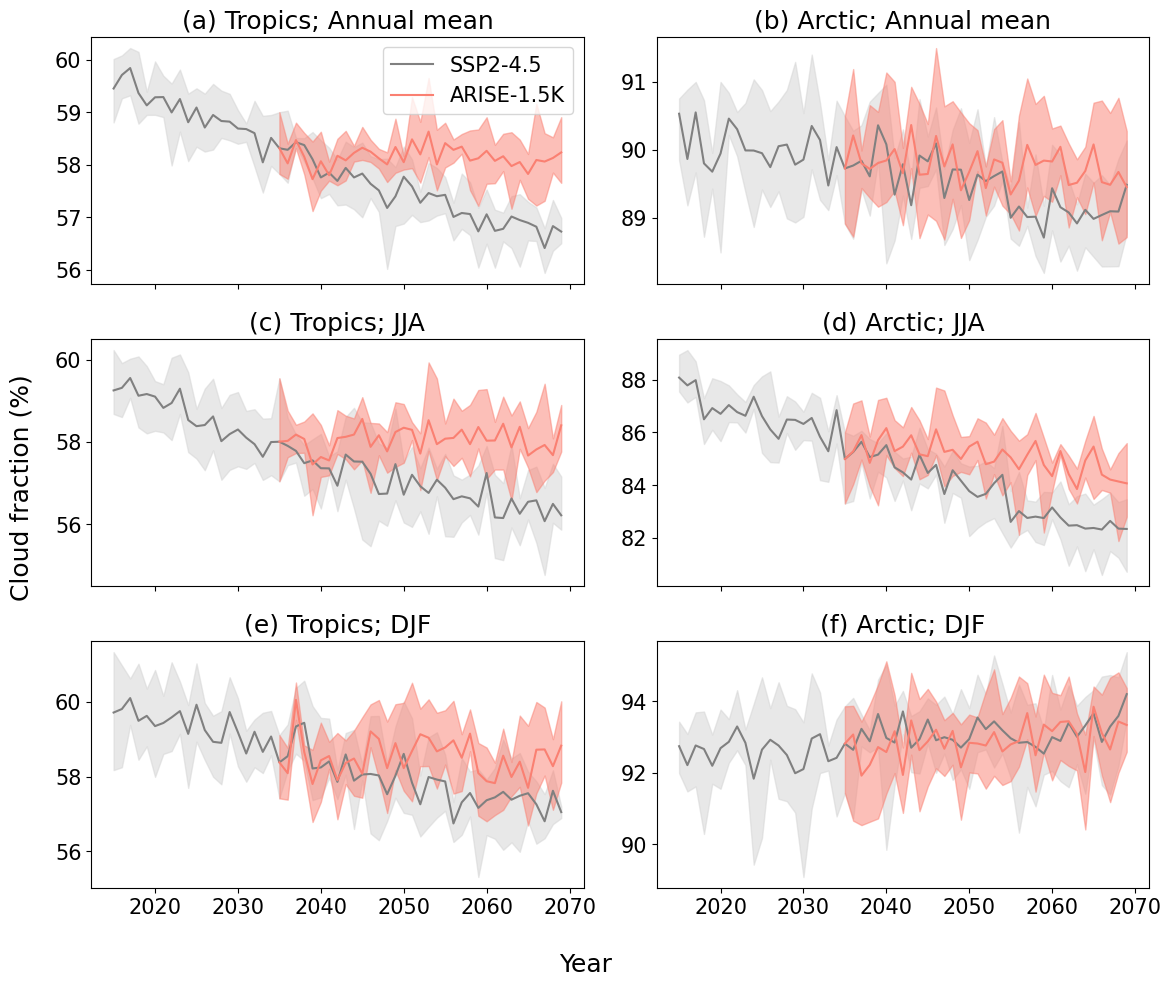

In [ ]:
fig, axs = plt.subplots(3, 2, figsize = (12, 10), sharey=False, sharex=True)
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',}


labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
k=0
i=0
for season in ['Annual mean', 'JJA', 'DJF']:
    j=0
    for region in ['Tropics', 'Arctic']:
        #ax = axs[0] if region == 'Tropics' else axs[1]
        ax = axs[i, j]
        ax.set_title('{l} {r}; {s}'.format(l=labs[k], r=region, s=season))
        
        

        # do for ssp245:
        ts_ssp245 = ssp245_clt_timeseries_dict[season][region].clt
        ax.plot(ts_ssp245.mean('Ensemble_member').year.values, ts_ssp245.mean('Ensemble_member'), c=colours['ssp245'], label='SSP2-4.5' if i==0 else None)
        ax.fill_between(ts_ssp245.isel(Ensemble_member=0).year.values, 
                        ts_ssp245.min('Ensemble_member').values, 
                        ts_ssp245.max('Ensemble_member').values, 
                        color=colours['ssp245_light'], alpha=0.5)
        # do same for ARISE: 
        ts_arise = arise_clt_timeseries_dict[season][region].clt
        ax.plot(ts_arise.mean('Ensemble_member').year.values, ts_arise.mean('Ensemble_member'), c='salmon', label='ARISE-1.5K' if i==0 else None)
        ax.fill_between(ts_arise.isel(Ensemble_member=0).year.values,
                        ts_arise.min('Ensemble_member').values, 
                        ts_arise.max('Ensemble_member').values, 
                        color='salmon', alpha=0.5)
        j=j+1
        k=k+1
    i=i+1
fig.supylabel('Cloud fraction (%)')
fig.supxlabel('Year')
axs[0, 0].legend()
plt.tight_layout()
plt.savefig('figures/Cloud_fraction_timeseries_SSP2-4.5_and_ARISE-1.5K.jpg', dpi=300, bbox_inches='tight')

In [ ]:
# hard to square the timeseries with the contributions above, e.g. how can clouds be causing warming under both GHG and SAI in the tropics
# given the restoration towards target seen above. Answer must be something to do with the cloud masking of other terms?

In [ ]:
arise_clt_map = DS_ARISE_clt.sel(time=slice(time_slice_dict['ARISE'][0], time_slice_dict['ARISE'][1])).mean('Ensemble_member')
arise_clt_map = arise_clt_map.groupby(arise_clt_map.time.dt.month).mean()

ssp245_map = DS_ssp245_clt.sel(time=slice(time_slice_dict['ssp245'][0], time_slice_dict['ssp245'][1])).mean('Ensemble_member')
ssp245_map = ssp245_map.groupby(ssp245_map.time.dt.month).mean()

ssp245_baseline_map = DS_ssp245_clt.sel(time=slice(time_slice_dict['ssp245_baseline'][0], time_slice_dict['ssp245_baseline'][1])).mean('Ensemble_member')
ssp245_baseline_map = ssp245_baseline_map.groupby(ssp245_baseline_map.time.dt.month).mean()

/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey

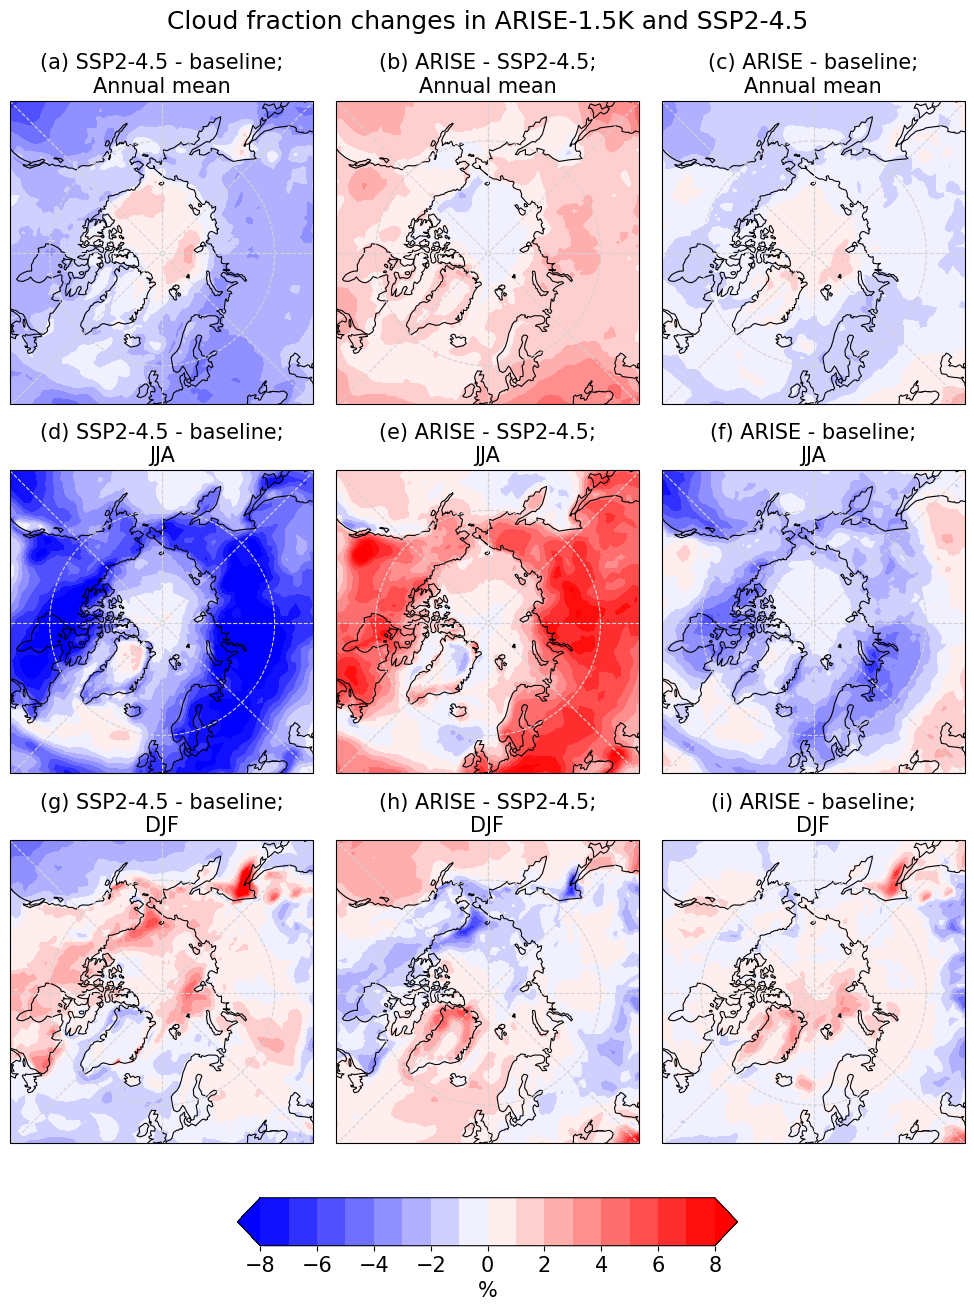

In [ ]:
## finally, plot maps of the cloud changes, for the three comparisons, and three seasons:

fig, axes = plt.subplots(3, 3, figsize=(10, 12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
extent = [-180, 180, 50, 90]
season_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
               'DJF': [12, 1, 2],
               'JJA': [6, 7, 8]}
levels = np.arange(-8, 8.5, 1)
i = 0

for season in ['Annual mean', 'JJA', 'DJF']:
    j=0
    for comparison in ['SSP2-4.5 - baseline', 'ARISE - SSP2-4.5', 'ARISE - baseline']:
        if comparison == 'ARISE - SSP2-4.5':
            data = arise_clt_map - ssp245_map
        elif comparison == 'SSP2-4.5 - baseline':
            data = ssp245_map - ssp245_baseline_map
        elif comparison == 'ARISE - baseline':
            data = arise_clt_map - ssp245_baseline_map
            
        data = data.where(data.month.isin(season_dict[season]), drop=True).mean('month')
        cyclic_data, cyclic_lons = add_cyclic_point(data['clt'].values, coord=data['longitude'])
        ax = axes.flatten()[i]
        cont = ax.contourf(cyclic_lons, data['latitude'], cyclic_data,
                           transform=ccrs.PlateCarree(),
                           levels=levels,
                           cmap='bwr',
                           extend='both')
        ax.set_title('({}) {};\n{}'.format(chr(97+i), comparison, season), fontsize='medium')
        ax.set_extent(extent, ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
        ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')

        i=i+1
        j=j+1

 

cbar_ax = fig.add_axes([0.25, -0.05, 0.5, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('%')
fig.suptitle('Cloud fraction changes in ARISE-1.5K and SSP2-4.5', fontsize='large')

plt.tight_layout()


plt.savefig('figures/Maps_cloud_fraction_changes_SSP2-4.5_and_ARISE-1.5K.jpg', dpi=300, bbox_inches='tight', pad_inches=0.2)